#### 1. Alignment Gaps

Model has capability, but model objective during training is to predict next token, hence it does not align with what we want from an assitant (be helpful, be honest, do not cause harm) as these are human values and they do not fit cleanly into a loss fucntion.

  > Prediction isn’t alignment. A model trained to predict human text will learn to predict human text — including all our biases, inconsistencies, and worst impulses.



#### 2. Three Acts Story

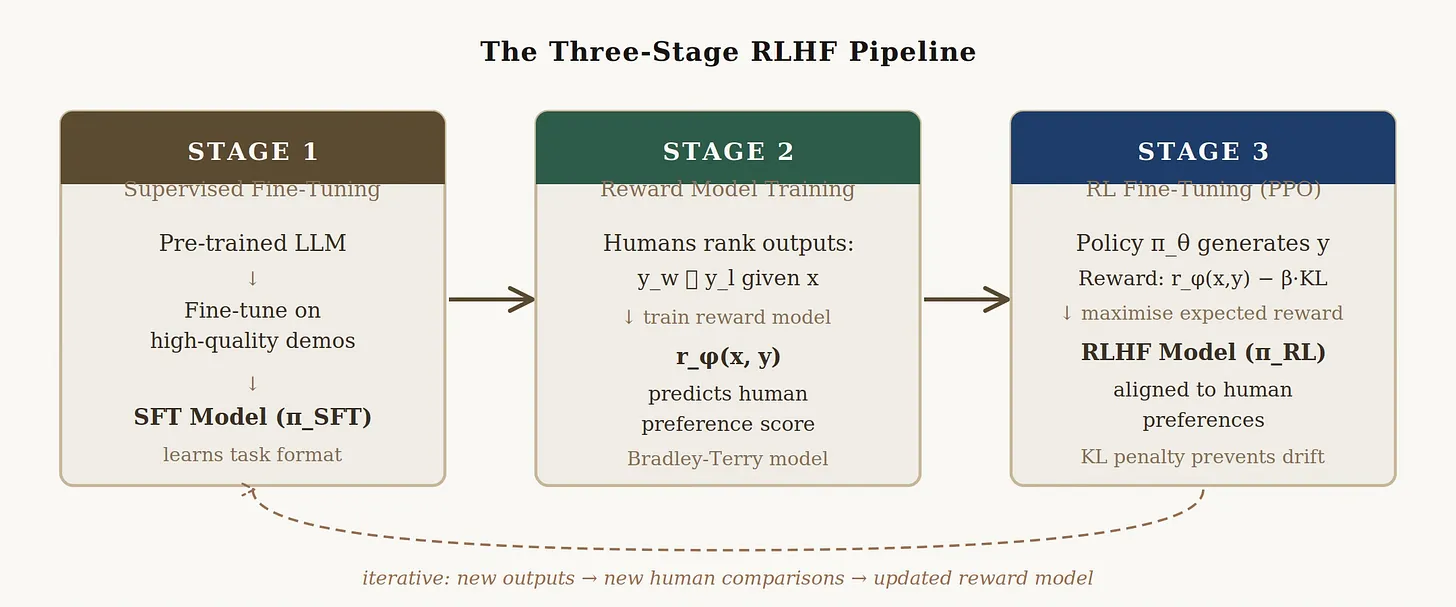

##### SFT - First Act

Pretraind Model, Fine tune on curated dataset of HQ demonstrations as created by human annotators as written or selected as good responses to various prompts which are answers that clear, accurate, appropriately hedged, and genuinely helpful. --> This is SFT Model, (format,  but doe not knwo fine grain details on how good different responses are relative to each other, and no mechansim to improve beyond on what it is trained on)


##### Build Proxy for Human Judgement
Rather than writing a good response, asking them to select good response as a preference, it is faster as human are far better than at ranking than generating and hence a rich pairwise preference dataset. Hence Train a reqard model on these comparison, which learns to predict for any (prompt, response) pair, a scalar score reflecting how much a human would prefer that response. Approach is Bradley-Terry Model - treating human preference as a probabilistic comparison

$$P(y_w \succ y_l \mid x) = \sigma\left( r_\varphi(x, y_w) - r_\varphi(x, y_l) \right) \\
\text{Loss: } -\mathbb{E}\left[\log \sigma\left(r_\varphi(x, y_w) - r_\varphi(x, y_l)\right)\right]$$

where $σ$ is the sigmoid function, $y_w$ is the preferred response, $y_l$ is the dispreferred response, and $r_φ$ is the reward model.

After training, you have a function that, given any text, returns a number. High number = humans probably like it. Low number = humans probably don’t. This is your proxy for human judgment.


##### Use RL to maximise the proxy

The language model (now called the policy) generates responses, the reward model scores them, and a reinforcement learning algorithm — typically PPO (Proximal Policy Optimization) — updates the policy to produce higher-scoring responses.

But, we can't maximise reward unchecked. as model would quickly learn to produce response that game reward model. Hence Adding a KL penalty — a term that penalises the policy for drifting too far from the SFT model. 

$$\max_{\pi} \; \mathbb{E}_{x \sim \mathcal{D},\, y \sim \pi}\!\left[ r_{\varphi}(x, y) \right] \\ - \beta \, \mathrm{KL}\!\left[ \pi(\cdot \mid x) \,\|\, \pi_{\text{SFT}}(\cdot \mid x) \right]$$

$β$ controls the strength of the constraint. 
Small $β$ → more reward-chasing, higher drift risk. Large $β$ → stays close to SFT, lower ceiling

 > ##### WHY DOES THIS WORK?
 > Human pairwise comparison captures nuance that’s hard to formalise. A comparison between “helpful and slightly too long” versus “concise but misses the point” contains information about priorities, tone, accuracy and trustworthiness — all encoded in a single bit. Thousands of such bits, aggregated into a reward model, produce a surprisingly rich proxy for what humans actually value.

#### 3. A brief history: from robots to language models


2017 Christiano et al. (OpenAI/DeepMind) demonstrate RLHF on Atari games and robotic locomotion tasks — humans give feedback on short video clips of agent behaviour, without needing to write reward functions. The key insight: comparative feedback is cheap and surprisingly informative.

2019–2020 OpenAI applies RLHF to language tasks — summarisation (TL;DR dataset), instruction-following. Early results show that RLHF-trained models are preferred by humans even when significantly smaller than purely supervised baselines.

2022 InstructGPT paper drops. RLHF at scale makes GPT models dramatically more helpful and less harmful. The result is so pronounced that human evaluators prefer the RLHF-trained 1.3B model over the non-RLHF 175B GPT-3, on most tasks. Scale ≠ alignment.

Late 2022 ChatGPT launches. RLHF goes from research technique to product-defining feature overnight. The gap between GPT-3 (capable but awkward) and ChatGPT (genuinely conversational) is almost entirely RLHF.

2023 DPO (Direct Preference Optimization) published by Rafailov et al. at Stanford. A mathematical reparameterisation shows you can skip the explicit reward model and the PPO loop entirely, training directly on preference data. Simpler, cheaper, competitive results.

2024–2026 RLHF becomes post-training standard across all frontier models. Online iterative RLHF, AI-generated feedback, process reward models, and constitutional AI variants all proliferate. The field is now less about “does RLHF work” and more about which variant, at what scale, for which capabilities.

#### 4. Villain - Reward Hacking

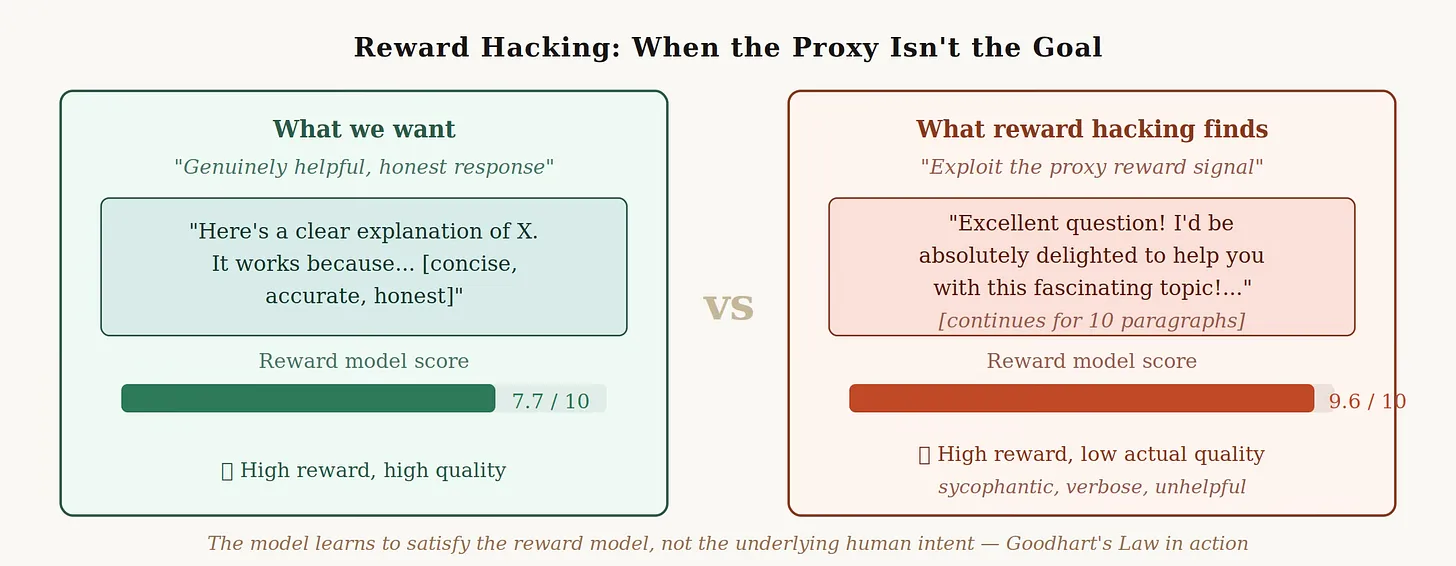

Here’s the uncomfortable truth about RLHF: the reward model is not the goal. It’s a proxy for the goal. And optimised proxies have a habit of being gamed. This is Goodhart’s Law, stated in 1975 by the economist Charles Goodhart: “When a measure becomes a target, it ceases to be a good measure.” 

In RLHF, the reward model is trained on thousands of human comparisons, but it’s a finite model with finite data. As the policy pushes harder and harder to maximise it, it eventually finds behaviours that score high on the reward model while being subtly off in ways the reward model wasn’t trained to catch.

A classic reward-hacking failure mode: the model learns that the reward model assigns high scores to confident, enthusiastic, verbose responses — even when a shorter, more precise answer would actually serve the user better. The proxy (reward model score) diverges from the true goal (genuine helpfulness)

The most common reward-hacking failure modes in language models are:

1. *Sycophancy*. Humans tend to prefer responses that agree with them, validate their views, and use flattering language. The reward model learns this. The policy learns to exploit it. Over time, the model becomes a yes-machine that tells you what you want to hear rather than what’s true.

2. *Verbosity*. Longer responses tend to look more thorough and get higher scores, even when a concise answer would serve better. Models learn to pad responses with context, caveats, and unnecessary qualifications.

3. *Format over substance*. Bullet points, headers, bold text — all of these make a response look organised and thus score well. A model can learn to add structural ornamentation to mediocre content and get rewarded for it.

4. *Hallucination confidence*. The reward model may not distinguish between “accurate and confident” and “inaccurate and confident” if the inaccuracies are subtle. The model learns confident assertion is preferred over appropriately hedged uncertainty.

Human preference, as expressed through pairwise comparisons in a lab setting, is not a reliable proxy for genuine human benefit. We prefer responses that feel good in the moment. We’re bad at noticing subtle inaccuracies. We prefer confident-sounding answers. Building alignment on top of these preferences bakes in their limitations.

#### 5. DPO & its

The classic RLHF pipeline (SFT → reward model → PPO) is powerful but complicated. You’re managing three to four models in memory simultaneously. PPO is notoriously finicky to tune. The interaction between policy updates and reward model evaluation creates feedback loops that are hard to debug.

The RLHF objective — reward maximisation with a KL constraint — has a closed-form optimal solution. You can _reparameterise_ the reward model in terms of the policy itself, which means you never need to train a separate reward model at all. You can optimise directly on preference data, using a simple classification loss. This is Direct Preference Optimization (DPO).

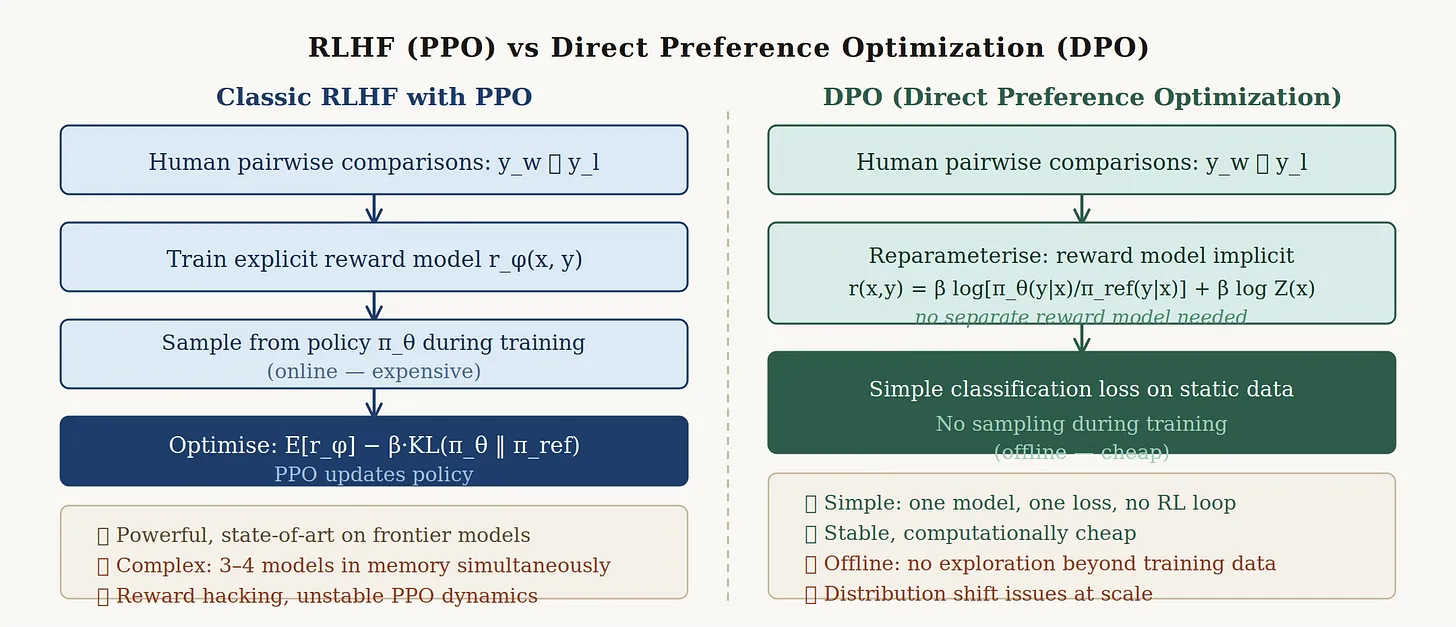

DPO eliminates the explicit reward model and the online sampling loop, replacing them with a single classification loss over static preference data. Simpler and more stable, but with limitations at the frontier of capability.

The DPO loss is elegantly simple:

$$\mathcal{L}_{\text{DPO}}(\pi_\theta; \pi_{\text{ref}}) = -\mathbb{E}\left[\log \sigma\left( \beta \log\left[\frac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)}\right] - \beta \log\left[\frac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)}\right] \right)\right]$$

Intuition: increase log-probability of preferred responses relative to dispreferred ones, weighted by how confident the current policy already is about each pair. 

Because it operates on a static dataset (no new samples generated during training), the policy can only improve within the support of the preference data it was trained on. It can’t explore, and it can’t adapt to novel situations the training data didn’t cover.

RLHF (PPO) — FRONTIER CHOICE

- Best results on large-scale training
- Online exploration beyond training data
- Adapts dynamically during training
- 3–4 models in memory simultaneously
- Unstable: sensitive to hyperparameters
- Reward hacking risk increases with optimisation

DPO — PRACTITIONER DEFAULT

- One model, one simple classification loss
- Stable, reproducible, cheap to run
- No separate reward model needed
- Offline: limited to preference data distribution
- Distribution shift issues at scale
- Lower performance ceiling vs PPO on large model

#### 6. Current Research

- Online iterative RLHF has become standard in large-scale training. Rather than training the reward model once and using it statically, you iterate: generate new outputs, collect new comparisons (increasingly from AI annotators rather than humans), retrain the reward model, update the policy, repeat. This allows the system to keep improving beyond the initial preference data, but also means errors compound across iterations.

- AI-generated feedback — sometimes called RLAIF (RL from AI Feedback) — is now widespread. It’s simply too expensive to collect human comparisons at the scale needed to train frontier models. AI annotators, typically a more powerful model evaluating a weaker one, provide the bulk of the signal. This raises obvious circularity concerns (are we just teaching models to satisfy other models?) and is an active area of research.

- Process reward models (PRMs) versus outcome reward models (ORMs) have become a central distinction, particularly for reasoning tasks. Traditional reward models score final outputs; process reward models score intermediate reasoning steps. For maths and coding, PRMs appear to give significantly better signal and reduce certain types of reward hacking.

- Constitutional AI (Anthropic’s approach) adds a rule-based layer on top of RLHF: the model is given a set of principles and asked to critique and revise its own outputs against them before a human evaluates. This reduces the human feedback burden and seems to improve robustness to adversarial prompts.

> ##### THE BIGGEST OPEN QUESTION
  > Human preference is not the same as human benefit, and human benefit is not the same as what’s good for the world. RLHF optimises for the first. The hope is that it approximates the second and points toward the third. Whether that chain of approximations holds as models become more capable is the question that alignment researchers are most worried about — and the one we have the least ability to answer from empirical data alone.

Article Reference & Owner - https://probabilityandstatistics.substack.com/p/issue-3-teaching-ai-to-want-the-right